# NLP Deep Learning Project - Part 2

Authors: Bezalel Spolter and Yair Shmueli

# Imports

In [ ]:
import torch
import torch.nn as nn
from sklearn.metrics import classification_report, accuracy_score, f1_score, confusion_matrix
import pandas as pd
import numpy as np
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
import torch.optim as optim
from collections import Counter
import re
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
import os
import random
from sklearn.model_selection import ParameterGrid
from tqdm.auto import tqdm
from datasets import Dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
import seaborn as sns
pd.set_option('display.max_colwidth', None)

# Data Processing

We do the following steps for preprocessing data:  
1. Take non-string values and convert them into empty strings
2. Lowercase everything
3. Open up contractions to their full form (e.g. from im to i am). This is so a model which was trained on real vocabulary can "recognize" these words.
4. Remove duplicates of syllables which are more than 2 letters long to 2 letters (e.g. from wheeeeeeeeee to whee). Same reason.
5. Remove punctuation
6. Remove double spaces so there is one space max between words<br>(7. We wanted to remove all emojies but we noticed there are none in the dataset)

In [6]:
train_df = pd.read_csv('train.csv')
val_df = pd.read_csv('validation.csv')

In [7]:
train_df.head()

,text,label
0,i didnt feel humiliated,0
1,i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake,0
2,im grabbing a minute to post i feel greedy wrong,3
3,i am ever feeling nostalgic about the fireplace i will know that it is still on the property,2
4,i am feeling grouchy,3


In [ ]:
print(train_df['label'].value_counts())
print(val_df['label'].value_counts())

In [ ]:

# Define a comprehensive mapping for informal contractions
CONTRACTIONS_MAP = {
    "im": "i am",
    "didnt": "did not",
    "dont": "do not",
    "ive": "i have",
    "wasnt": "was not",
    "isnt": "is not",
    "cant": "cannot",
    "couldnt": "could not",
    "wont": "will not",
    "shouldnt": "should not",
    "wouldnt": "would not",
    "arent": "are not",
    "havent": "have not",
    "hasnt": "has not",
    "thats": "that is",
    "theres": "there is",
    "youre": "you are",
    "theyre": "they are",
    "weve": "we have",
}

def clean_tweet_text(text):
    if not isinstance(text, str):
        return ""

    # Lowercase everything
    text = text.lower()

    # Expand Contractions
    # We split into words, replace if in map, and join back
    words = text.split()
    expanded_words = [CONTRACTIONS_MAP[w] if w in CONTRACTIONS_MAP else w for w in words]
    text = " ".join(expanded_words)

    # Remove 3+ subsequent letters to 2 letters
    text = re.sub(r'(.)\1{2,}', r'\1\1', text)

    # Remove Punctuation
    text = re.sub(r'[^\w\s]', '', text)

    # whitespace cleanup
    text = " ".join(text.split())

    return text

# Apply to your DataFrame
train_df['text'] = train_df['text'].apply(clean_tweet_text)

# Check the results
print(train_df[['text']].head(10))

                                                                                                                               text
0                                                                                                         i did not feel humiliated
1                      i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake
2                                                                                i am grabbing a minute to post i feel greedy wrong
3                                      i am ever feeling nostalgic about the fireplace i will know that it is still on the property
4                                                                                                              i am feeling grouchy
5                                                            i have been feeling a little burdened lately was not sure why that was
6  i have been taking or milligrams or times recommended amount and i have f

# Classification - RoBerta

In [ ]:
# 1. Initialize Tokenizer
tokenizer = AutoTokenizer.from_pretrained("cardiffnlp/twitter-roberta-base-sentiment")

# 2. Tokenization Function
def tokenize_function(examples):
    return tokenizer(examples["text"], padding="max_length", truncation=True, max_length=128)

# 3. Convert Pandas to Hugging Face Dataset
train_dataset = Dataset.from_pandas(train_df[['text', 'label']])
val_dataset = Dataset.from_pandas(val_df[['text', 'label']])

# 4. Map Tokenization
tokenized_train = train_dataset.map(tokenize_function, batched=True)
tokenized_val = val_dataset.map(tokenize_function, batched=True)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/747 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/150 [00:00<?, ?B/s]

Map:   0%|          | 0/16000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Output of the previous block on Google Colab (for some reason did not download well): <br>
config.json: 100%
 747/747 [00:00<00:00, 56.1kB/s]
vocab.json: 
 899k/? [00:00<00:00, 22.1MB/s]
merges.txt: 
 456k/? [00:00<00:00, 19.0MB/s]
special_tokens_map.json: 100%
 150/150 [00:00<00:00, 13.9kB/s]
Map: 100%
 16000/16000 [00:02<00:00, 7051.39 examples/s]
Map: 100%
 2000/2000 [00:00<00:00, 7328.68 examples/s]

In [ ]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)

    acc = accuracy_score(labels, predictions)
    f1 = f1_score(labels, predictions, average='macro')

    return {
        'accuracy': acc,
        'f1_macro': f1
    }

# Baseline Hyperparameters
training_args = TrainingArguments(
    learning_rate=2e-5,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,
    num_train_epochs=5,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    warmup_steps=500,
    report_to="none",
    logging_strategy="epoch",
    logging_steps=1,
)

# Load model for 6 classes
model = AutoModelForSequenceClassification.from_pretrained(
    "cardiffnlp/twitter-roberta-base-sentiment",
    num_labels=6,
    ignore_mismatched_sizes=True
)

# Setting up Fine-Tuning Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_val,
    compute_metrics=compute_metrics,
)

pytorch_model.bin:   0%|          | 0.00/499M [00:00<?, ?B/s]

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at cardiffnlp/twitter-roberta-base-sentiment and are newly initialized because the shapes did not match:
- classifier.out_proj.weight: found shape torch.Size([3, 768]) in the checkpoint and torch.Size([6, 768]) in the model instantiated
- classifier.out_proj.bias: found shape torch.Size([3]) in the checkpoint and torch.Size([6]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Part of output of previous block on Google Colab (which didn't download well):<br>
pytorch_model.bin: 100%
 499M/499M [00:07<00:00, 93.9MB/s] 
model.safetensors: 100%
 499M/499M [00:03<00:00, 211MB/s]

Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,0.908000,0.270484,0.912000,0.886835
2,0.230600,0.177739,0.930500,0.903650
3,0.141800,0.164813,0.935500,0.916409
4,0.105200,0.157274,0.935500,0.909795
5,0.084800,0.157469,0.936500,0.910569



Total Training Runtime: 1844.96 seconds (30.75 minutes)
Model Size: 124.65 Million parameters

Epoch Summary Table:
Epoch   | Train Loss   | Val Loss     | Val Acc      | Val F1      
----------------------------------------------------------------------
1.0     | 0.908000     | 0.270484     | 0.912000     | 0.886835    
2.0     | 0.230600     | 0.177739     | 0.930500     | 0.903650    
3.0     | 0.141800     | 0.164813     | 0.935500     | 0.916409    
4.0     | 0.105200     | 0.157274     | 0.935500     | 0.909795    
5.0     | 0.084800     | 0.157469     | 0.936500     | 0.910569    


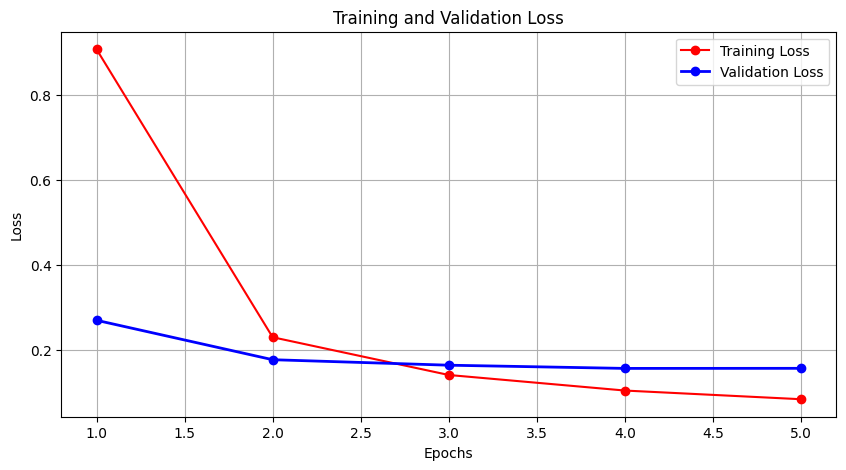

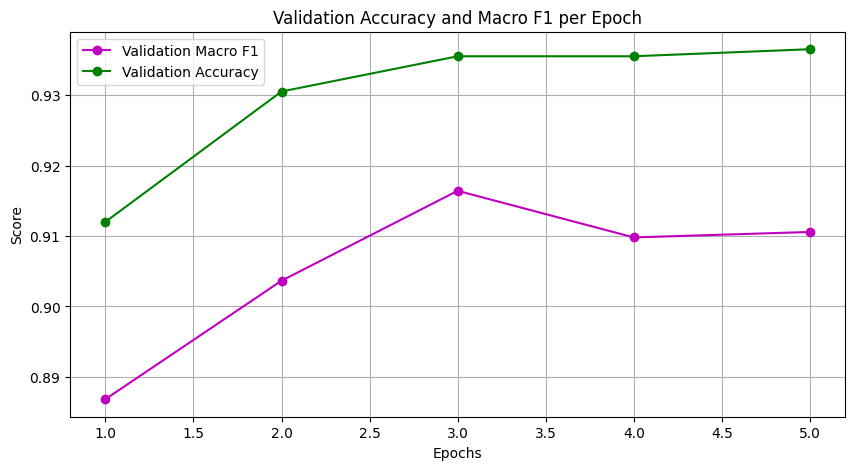

In [ ]:
# Train the model and capture results
train_result = trainer.train()

# Print Runtime and Model Size
runtime = train_result.metrics.get("train_runtime", 0)
print(f"\nTotal Training Runtime: {runtime:.2f} seconds ({runtime/60:.2f} minutes)")

num_params = model.num_parameters()
print(f"Model Size: {num_params / 1e6:.2f} Million parameters")


# Extracting history
history = trainer.state.log_history

# Initialize lists for all metrics
metrics = {
    "train_loss": [], "val_loss": [],
    "val_acc": [], "val_f1": [],
    "epochs": []
}


print("\nEpoch Summary Table:")
print(f"{'Epoch':<7} | {'Train Loss':<12} | {'Val Loss':<12} | {'Val Acc':<12} | {'Val F1':<12}")
print("-" * 70)

# Process logs and print per-epoch results
for entry in history:
    if "eval_loss" in entry:
        epoch = entry["epoch"]
        v_loss = entry["eval_loss"]
        v_acc = entry.get("eval_accuracy", 0)
        f1_key = "eval_f1_macro" if "eval_f1_macro" in entry else "eval_macro_f1"
        v_f1 = entry.get(f1_key, 0)

        # Find the training loss that corresponds to this epoch
        t_loss = next((x["loss"] for x in history if x.get("epoch") == epoch and "loss" in x), None)

        # Print the row for the epoch summary
        print(f"{epoch:<7.1f} | {t_loss if t_loss else 0:<12.6f} | {v_loss:<12.6f} | {v_acc:<12.6f} | {v_f1:<12.6f}")

        # Store metrics
        metrics["epochs"].append(epoch)
        metrics["train_loss"].append(t_loss)
        metrics["val_loss"].append(v_loss)
        metrics["val_acc"].append(v_acc)
        metrics["val_f1"].append(v_f1)

# Plot 1: Training vs Validation Loss
plt.figure(figsize=(10, 5))
if any(m is not None for m in metrics["train_loss"]):
    plt.plot(metrics["epochs"], metrics["train_loss"], 'r-o', label='Training Loss')
plt.plot(metrics["epochs"], metrics["val_loss"], 'b-o', linewidth=2, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

# Plot 2: Validation Metrics
plt.figure(figsize=(10, 5))
plt.plot(metrics["epochs"], metrics["val_f1"], 'm-o', label='Validation Macro F1')
plt.plot(metrics["epochs"], metrics["val_acc"], 'g-o', label='Validation Accuracy')
plt.title('Validation Accuracy and Macro F1 per Epoch')
plt.xlabel('Epochs')
plt.ylabel('Score')
plt.legend()
plt.grid(True)
plt.show()


Final Macro F1 Score: 0.9164

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.97      0.96       550
           1       0.98      0.93      0.95       704
           2       0.81      0.98      0.88       178
           3       0.98      0.90      0.94       275
           4       0.91      0.88      0.89       212
           5       0.78      0.99      0.87        81

    accuracy                           0.94      2000
   macro avg       0.90      0.94      0.92      2000
weighted avg       0.94      0.94      0.94      2000



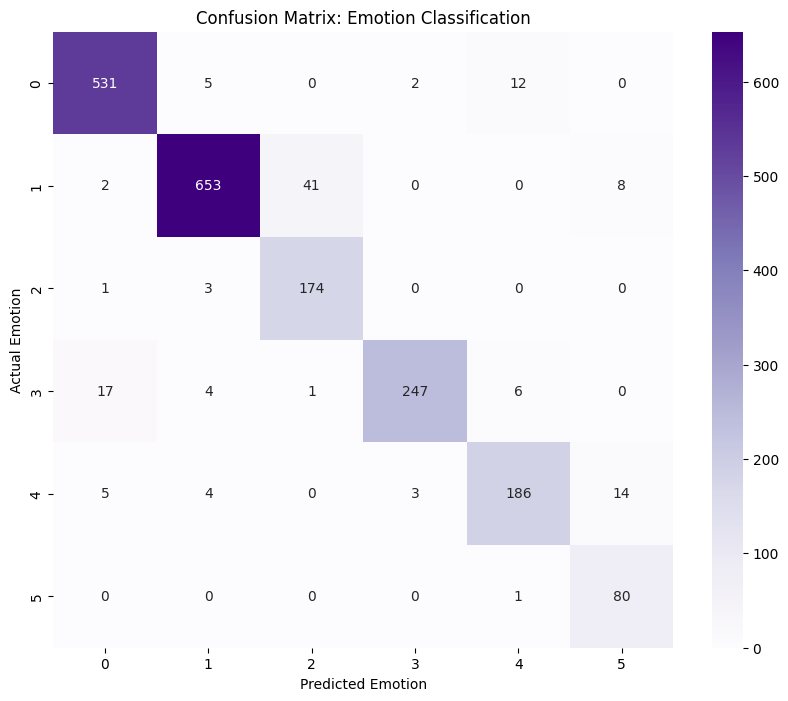

In [ ]:
# Generate finetuned model predictions
predictions_output = trainer.predict(tokenized_val)
y_pred = np.argmax(predictions_output.predictions, axis=-1)
y_true = val_df['label'].values

# Final finetuned model Macro F1
print(f"\nFinal Macro F1 Score: {f1_score(y_true, y_pred, average='macro'):.4f}")

# Final finetuned model Classification Report
print("\nClassification Report:")
print(classification_report(y_true, y_pred))

# Final finetuned model Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=range(6), yticklabels=range(6))
plt.xlabel('Predicted Emotion')
plt.ylabel('Actual Emotion')
plt.title('Confusion Matrix: Emotion Classification')
plt.show()

In [ ]:

# Saving the Model & Tokenizer

# Defining save directory
save_directory = "./Twitter_RoBERTa_model"

# Save the model
trainer.save_model(save_directory)

# Save the tokenizer
tokenizer.save_pretrained(save_directory)

print(f"Model and tokenizer saved to {save_directory}")

Model and tokenizer saved to ./Twitter_RoBERTa_model


# Classification - Bert

This model is BERTweet from https://huggingface.co/vinai/bertweet-base. Further information about the model is in our report

emoji is not installed, thus not converting emoticons or emojis into text. Install emoji: pip3 install emoji==0.6.0


Map:   0%|          | 0/16000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at vinai/bertweet-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipython-input-2868183792.py:42: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,1.156400,0.373273,0.913000,0.868426
2,0.272700,0.193183,0.934500,0.907155
3,0.155900,0.154293,0.935500,0.909902
4,0.110200,0.140938,0.939000,0.916302
5,0.089700,0.137453,0.939500,0.914629



Total Training Runtime: 1810.12 seconds (30.17 minutes)
Model Size: 134.90 Million parameters

Epoch Summary Table:
Epoch   | Train Loss   | Val Loss     | Val Acc      | Val F1      
----------------------------------------------------------------------
1.0     | 1.156400     | 0.373273     | 0.913000     | 0.868426    
2.0     | 0.272700     | 0.193183     | 0.934500     | 0.907155    
3.0     | 0.155900     | 0.154293     | 0.935500     | 0.909902    
4.0     | 0.110200     | 0.140938     | 0.939000     | 0.916302    
5.0     | 0.089700     | 0.137453     | 0.939500     | 0.914629    


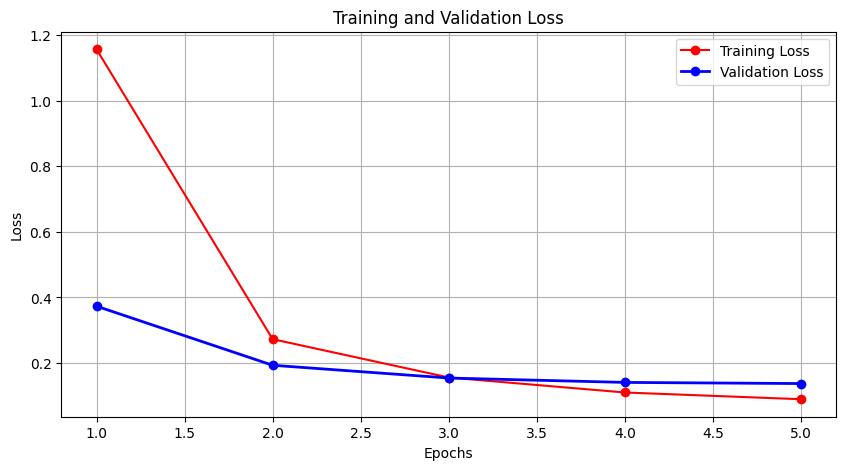

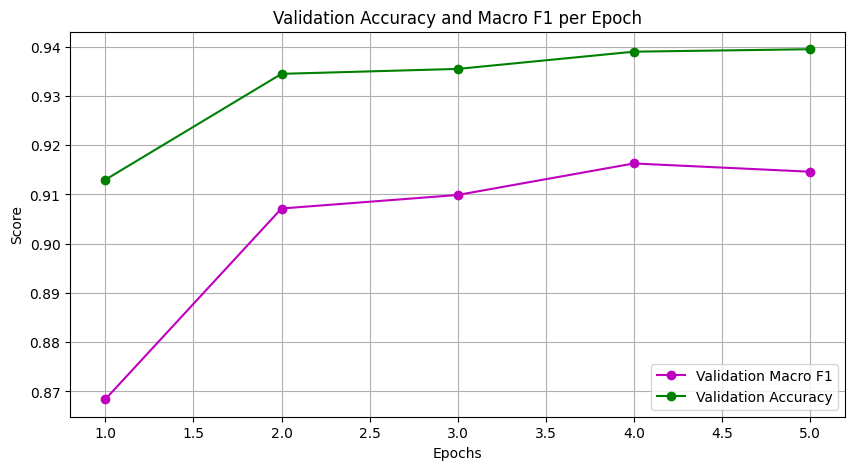

In [ ]:
model_name = "vinai/bertweet-base"

# Importing the tokenizer of the BERTweet model
tokenizer = AutoTokenizer.from_pretrained(model_name)

# new tokenization function which uses the imported tokenizer for BERTweet
def tokenize_function(examples):
    return tokenizer(examples["text"], padding="max_length", truncation=True, max_length=128)

# Convert Pandas to Hugging Face Dataset
train_dataset = Dataset.from_pandas(train_df[['text', 'label']])
val_dataset = Dataset.from_pandas(val_df[['text', 'label']])

# Map Tokenization
tokenized_train = train_dataset.map(tokenize_function, batched=True)
tokenized_val = val_dataset.map(tokenize_function, batched=True)

# Initialize BERTweet Model
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=6,
    ignore_mismatched_sizes=True
)

# Same Baseline Hyperparameters as before
training_args = TrainingArguments(
    learning_rate=2e-5,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,
    num_train_epochs=5,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    warmup_steps=500,
    report_to="none",
    logging_strategy="epoch",
    logging_steps=1,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_val,
    compute_metrics=compute_metrics,
    tokenizer=tokenizer
)



# Train the model and capture results
train_result = trainer.train()

# Print Runtime and Model Size
runtime = train_result.metrics.get("train_runtime", 0)
print(f"\nTotal Training Runtime: {runtime:.2f} seconds ({runtime/60:.2f} minutes)")

num_params = model.num_parameters()
print(f"Model Size: {num_params / 1e6:.2f} Million parameters")

# Extracting history
history = trainer.state.log_history

# Initialize lists for all metrics
metrics = {
    "train_loss": [], "val_loss": [],
    "val_acc": [], "val_f1": [],
    "epochs": []
}

print("\nEpoch Summary Table:")
print(f"{'Epoch':<7} | {'Train Loss':<12} | {'Val Loss':<12} | {'Val Acc':<12} | {'Val F1':<12}")
print("-" * 70)

# Process logs and print per-epoch results
for entry in history:
    if "eval_loss" in entry:
        epoch = entry["epoch"]
        v_loss = entry["eval_loss"]
        v_acc = entry.get("eval_accuracy", 0)
        f1_key = "eval_f1_macro" if "eval_f1_macro" in entry else "eval_macro_f1"
        v_f1 = entry.get(f1_key, 0)

        # Find the training loss that corresponds to this epoch
        t_loss = next((x["loss"] for x in history if x.get("epoch") == epoch and "loss" in x), None)

        # Print the row for the epoch summary
        print(f"{epoch:<7.1f} | {t_loss if t_loss else 0:<12.6f} | {v_loss:<12.6f} | {v_acc:<12.6f} | {v_f1:<12.6f}")

        # Store metrics
        metrics["epochs"].append(epoch)
        metrics["train_loss"].append(t_loss)
        metrics["val_loss"].append(v_loss)
        metrics["val_acc"].append(v_acc)
        metrics["val_f1"].append(v_f1)

# Plot 1: Training vs Validation Loss
plt.figure(figsize=(10, 5))
if any(m is not None for m in metrics["train_loss"]):
    plt.plot(metrics["epochs"], metrics["train_loss"], 'r-o', label='Training Loss')
plt.plot(metrics["epochs"], metrics["val_loss"], 'b-o', linewidth=2, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

# Plot 2: Validation Metrics
plt.figure(figsize=(10, 5))
plt.plot(metrics["epochs"], metrics["val_f1"], 'm-o', label='Validation Macro F1')
plt.plot(metrics["epochs"], metrics["val_acc"], 'g-o', label='Validation Accuracy')
plt.title('Validation Accuracy and Macro F1 per Epoch')
plt.xlabel('Epochs')
plt.ylabel('Score')
plt.legend()
plt.grid(True)
plt.show()

Part of output of previous block from Google Colab (didn't download well):<br>
Map: 100%
 16000/16000 [00:08<00:00, 1522.37 examples/s]
Map: 100%
 2000/2000 [00:00<00:00, 4040.56 examples/s]


Final Macro F1 Score: 0.9163

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.96      0.96       550
           1       0.96      0.95      0.96       704
           2       0.90      0.85      0.88       178
           3       0.96      0.92      0.94       275
           4       0.85      0.95      0.90       212
           5       0.84      0.89      0.86        81

    accuracy                           0.94      2000
   macro avg       0.91      0.92      0.92      2000
weighted avg       0.94      0.94      0.94      2000



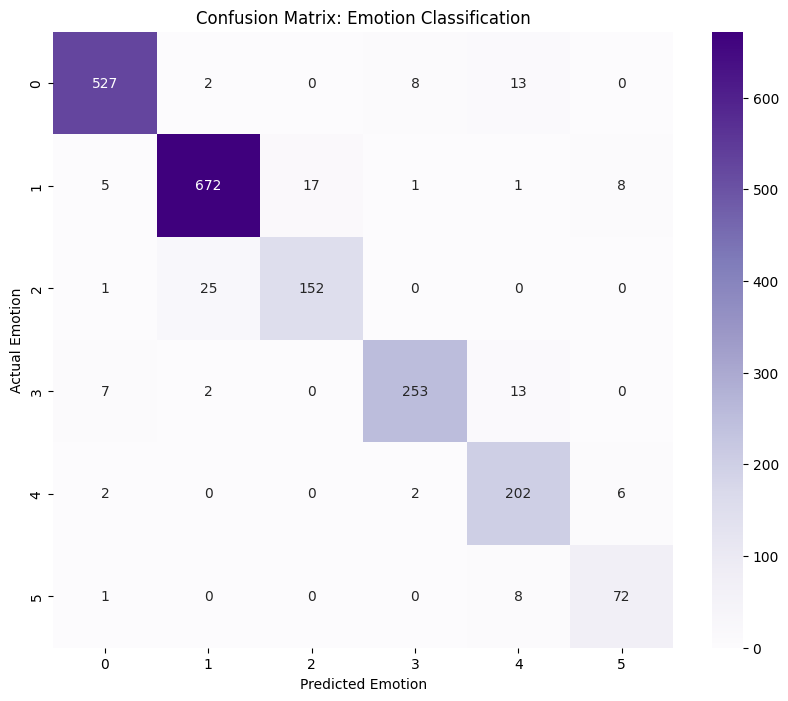

In [ ]:
# Generate fine-tuned model predictions
predictions_output = trainer.predict(tokenized_val)
y_pred = np.argmax(predictions_output.predictions, axis=-1)
y_true = val_df['label'].values

# fine-tuned model Macro F1
print(f"\nFinal Macro F1 Score: {f1_score(y_true, y_pred, average='macro'):.4f}")

# fine-tuned model Classification Report
print("\nClassification Report:")
print(classification_report(y_true, y_pred))

# fine-tuned model confusion Matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples')
plt.xlabel('Predicted Emotion')
plt.ylabel('Actual Emotion')
plt.title('Confusion Matrix: Emotion Classification')
plt.show()

In [ ]:
# Saving the Model & Tokenizer

save_directory = "./BERTweet_model"

trainer.save_model(save_directory)

tokenizer.save_pretrained(save_directory)

print(f"\nModel and tokenizer successfully saved to: {save_directory}")


Model and tokenizer successfully saved to: ./BERTweet_model


# Classification - DeBerta V3

This model is DeBERTA V2 from https://huggingface.co/microsoft/deberta-v3-base. Further information about the model is in our report. This is the only model we used which didn't have prior information about tweets

tokenizer_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/579 [00:00<?, ?B/s]

spm.model:   0%|          | 0.00/2.46M [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/transformers/convert_slow_tokenizer.py:566: UserWarning: The sentencepiece tokenizer that you are converting to a fast tokenizer uses the byte fallback option which is not implemented in the fast tokenizers. In practice this means that the fast version of the tokenizer can produce unknown tokens whereas the sentencepiece version would have converted these unknown tokens into a sequence of byte tokens matching the original piece of text.
  warnings.warn(


pytorch_model.bin:   0%|          | 0.00/371M [00:00<?, ?B/s]

...

Map:   0%|          | 0/16000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

/tmp/ipython-input-3981522235.py:17: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(
The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 2, 'bos_token_id': 1}.


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,1.114300,0.344400,0.900000,0.868891
2,0.236900,0.172168,0.940500,0.915548
3,0.140900,0.152504,0.933500,0.908126
4,0.105400,0.146864,0.940000,0.914625
5,0.084700,0.160150,0.939000,0.913507



Total Training Runtime: 1392.93 seconds (23.22 minutes)
Model Size: 184.43 Million parameters

Epoch Summary Table:
Epoch   | Train Loss   | Val Loss     | Val Acc      | Val F1      
----------------------------------------------------------------------
1.0     | 1.114300     | 0.344400     | 0.900000     | 0.868891    
2.0     | 0.236900     | 0.172168     | 0.940500     | 0.915548    
3.0     | 0.140900     | 0.152504     | 0.933500     | 0.908126    
4.0     | 0.105400     | 0.146864     | 0.940000     | 0.914625    
5.0     | 0.084700     | 0.160150     | 0.939000     | 0.913507    


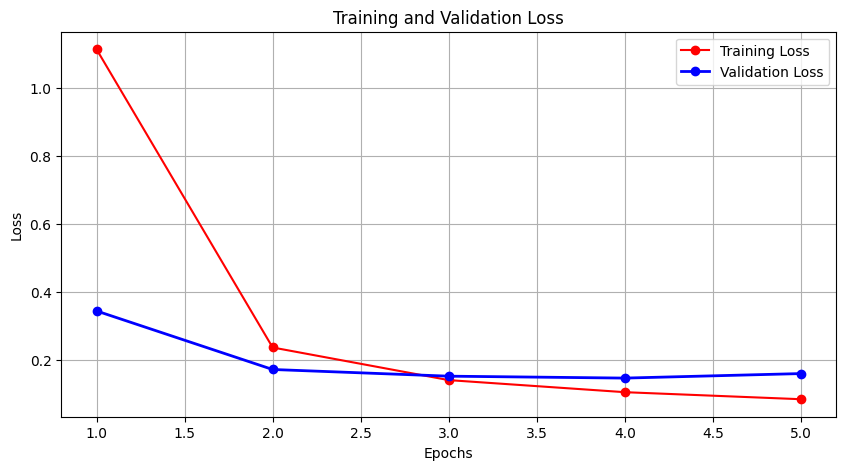

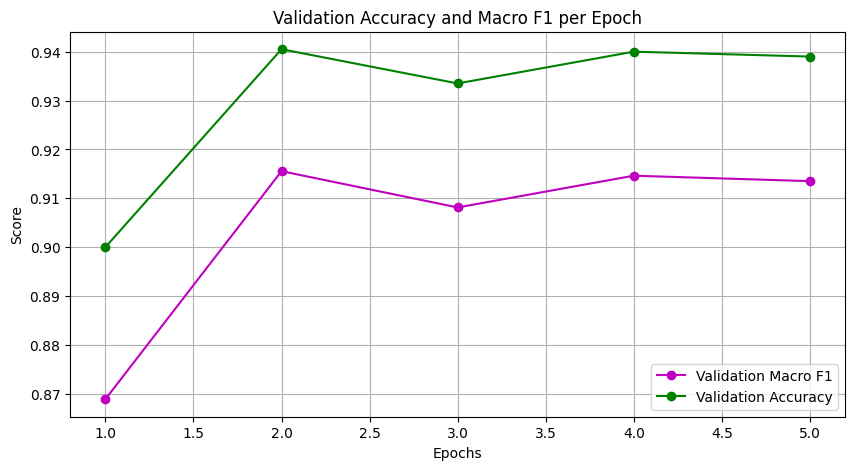

In [ ]:
model_name = "microsoft/deberta-v3-base"

# Importing the tokenizer of the DeBERTA V3 model
tokenizer = AutoTokenizer.from_pretrained(model_name)


# Initialize Model (Sequence Classification)
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=6,
    ignore_mismatched_sizes=True
)

# new tokenization function which uses the imported tokenizer for DeBERTA V3
def tokenize_function(examples):
     return tokenizer(examples["text"], truncation=True, max_length=128)

tokenized_train = train_dataset.map(tokenize_function, batched=True)
tokenized_val = val_dataset.map(tokenize_function, batched=True)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_val,
    compute_metrics=compute_metrics,
    tokenizer=tokenizer
)

# Train the model and capture results
train_result = trainer.train()

# Print Runtime and Model Size
runtime = train_result.metrics.get("train_runtime", 0)
print(f"\nTotal Training Runtime: {runtime:.2f} seconds ({runtime/60:.2f} minutes)")

num_params = model.num_parameters()
print(f"Model Size: {num_params / 1e6:.2f} Million parameters")

# Extracting history
history = trainer.state.log_history

# Initialize lists for all metrics
metrics = {
    "train_loss": [], "val_loss": [],
    "val_acc": [], "val_f1": [],
    "epochs": []
}

print("\nEpoch Summary Table:")
print(f"{'Epoch':<7} | {'Train Loss':<12} | {'Val Loss':<12} | {'Val Acc':<12} | {'Val F1':<12}")
print("-" * 70)

# Process logs and print per-epoch results
for entry in history:
    if "eval_loss" in entry:
        epoch = entry["epoch"]
        v_loss = entry["eval_loss"]
        v_acc = entry.get("eval_accuracy", 0)
        f1_key = "eval_f1_macro" if "eval_f1_macro" in entry else "eval_macro_f1"
        v_f1 = entry.get(f1_key, 0)

        # Find the training loss that corresponds to this epoch
        t_loss = next((x["loss"] for x in history if x.get("epoch") == epoch and "loss" in x), None)

        # Print the row for the epoch summary
        print(f"{epoch:<7.1f} | {t_loss if t_loss else 0:<12.6f} | {v_loss:<12.6f} | {v_acc:<12.6f} | {v_f1:<12.6f}")

        # Store metrics
        metrics["epochs"].append(epoch)
        metrics["train_loss"].append(t_loss)
        metrics["val_loss"].append(v_loss)
        metrics["val_acc"].append(v_acc)
        metrics["val_f1"].append(v_f1)

# Plot 1: Training vs Validation Loss
plt.figure(figsize=(10, 5))
if any(m is not None for m in metrics["train_loss"]):
    plt.plot(metrics["epochs"], metrics["train_loss"], 'r-o', label='Training Loss')
plt.plot(metrics["epochs"], metrics["val_loss"], 'b-o', linewidth=2, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

# Plot 2: Validation Metrics
plt.figure(figsize=(10, 5))
plt.plot(metrics["epochs"], metrics["val_f1"], 'm-o', label='Validation Macro F1')
plt.plot(metrics["epochs"], metrics["val_acc"], 'g-o', label='Validation Accuracy')
plt.title('Validation Accuracy and Macro F1 per Epoch')
plt.xlabel('Epochs')
plt.ylabel('Score')
plt.legend()
plt.grid(True)
plt.show()

Part of output of previous block from Google Colab (didn't download well):<br>
tokenizer_config.json: 100%
 52.0/52.0 [00:00<00:00, 3.77kB/s]
config.json: 100%
 579/579 [00:00<00:00, 70.6kB/s]
spm.model: 100%
 2.46M/2.46M [00:00<00:00, 4.67MB/s]
/usr/local/lib/python3.12/dist-packages/transformers/convert_slow_tokenizer.py:566: UserWarning: The sentencepiece tokenizer that you are converting to a fast tokenizer uses the byte fallback option which is not implemented in the fast tokenizers. In practice this means that the fast version of the tokenizer can produce unknown tokens whereas the sentencepiece version would have converted these unknown tokens into a sequence of byte tokens matching the original piece of text.
  warnings.warn(
pytorch_model.bin: 100%
 371M/371M [00:13<00:00, 25.4MB/s]
model.safetensors: 100%
 371M/371M [00:07<00:00, 57.4MB/s]
Some weights of DebertaV2ForSequenceClassification were not initialized from the model checkpoint at microsoft/deberta-v3-base and are newly initialized: ['classifier.bias', 'classifier.weight', 'pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Map: 100%
 16000/16000 [00:03<00:00, 7689.98 examples/s]
Map: 100%
 2000/2000 [00:00<00:00, 12921.55 examples/s]


Final Macro F1 Score: 0.9155

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.95      0.96       550
           1       0.95      0.97      0.96       704
           2       0.94      0.83      0.88       178
           3       0.93      0.96      0.94       275
           4       0.88      0.92      0.90       212
           5       0.79      0.90      0.84        81

    accuracy                           0.94      2000
   macro avg       0.91      0.92      0.92      2000
weighted avg       0.94      0.94      0.94      2000



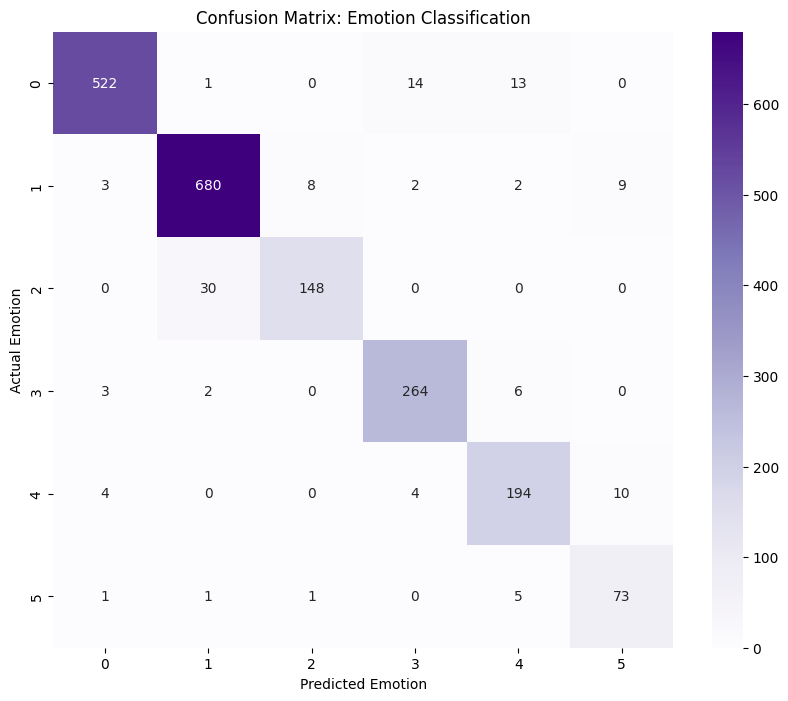

In [ ]:
# Generate fine-tuned model predictions
predictions_output = trainer.predict(tokenized_val)
y_pred = np.argmax(predictions_output.predictions, axis=-1)
y_true = val_df['label'].values

# fine-tuned model Macro F1
print(f"\nFinal Macro F1 Score: {f1_score(y_true, y_pred, average='macro'):.4f}")

# fine-tuned model Classification Report
print("\nClassification Report:")
print(classification_report(y_true, y_pred))

# fine-tuned model Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples')
plt.xlabel('Predicted Emotion')
plt.ylabel('Actual Emotion')
plt.title('Confusion Matrix: Emotion Classification')
plt.show()

In [ ]:
# Saving the Model & Tokenizer

save_directory = "./DeBERTa_V3_model"

trainer.save_model(save_directory)

tokenizer.save_pretrained(save_directory)

print(f"\nModel and tokenizer successfully saved to: {save_directory}")


Model and tokenizer successfully saved to: ./DeBERTa_V3_model


# Classification - Finding the Best Model

Here we use t-test to compare results of each model. We pair each model with another and for each measure (precision, recall and f1) we see if there is difference.<br>
To do this we import the weights and tokenizers of each model and for each model tokenize the validation dataset and predict.
Then compare results

In [ ]:
import scipy.stats as stats

# Getting datasets, models, and tokenizers ready, and defining training args to be the same as before

train_dataset = Dataset.from_pandas(train_df[['text', 'label']])
val_dataset = Dataset.from_pandas(val_df[['text', 'label']])


model_paths = {
    "Twitter-RoBERTa": "./Twitter_RoBERTa_model",
    "BERTweet": "./BERTweet_model",
    "DeBERTa-V3": "./DeBERTa_V3_model"
}


training_args = TrainingArguments(
    learning_rate=2e-5,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,
    num_train_epochs=5,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    warmup_steps=500,
    report_to="none",
    logging_strategy="epoch",
    logging_steps=1,
)

results = {}

# Training args for prediction
predict_args = TrainingArguments(
    output_dir="./temp_stats_output",
    per_device_eval_batch_size=32,
    report_to="none"
)


# Evaluation Loop (With Re-Tokenization)


print("Starting evaluation of all models...\n")

for model_name, path in model_paths.items():
    print(f"Processing {model_name}...")

    try:
        # Load Model & Tokenizer for this specific architecture
        tokenizer = AutoTokenizer.from_pretrained(path)
        model = AutoModelForSequenceClassification.from_pretrained(path)

        # Re-tokenize the validation data for this specific tokenizer
        def tokenize_function(examples):
            return tokenizer(examples["text"], truncation=True, padding="max_length", max_length=128)

        print(f"Re-tokenizing validation set for {model_name}...")

        current_tokenized_val = val_dataset.map(tokenize_function, batched=True, load_from_cache_file=False)

        # Initialize Trainer
        trainer = Trainer(
            model=model,
            args=predict_args,
            tokenizer=tokenizer
        )

        # Predict
        preds_output = trainer.predict(current_tokenized_val)
        y_pred = np.argmax(preds_output.predictions, axis=-1)
        y_true = preds_output.label_ids

        # Calculate Metrics
        report = classification_report(y_true, y_pred, output_dict=True)

        metrics_arrays = {
            "precision": [report[str(i)]['precision'] for i in range(6)],
            "recall":    [report[str(i)]['recall'] for i in range(6)],
            "f1":        [report[str(i)]['f1-score'] for i in range(6)]
        }

        macro_f1 = f1_score(y_true, y_pred, average='macro')

        results[model_name] = {
            "macro_f1": macro_f1,
            "metrics": metrics_arrays
        }
        print(f"-> {model_name} Finished. Macro F1: {macro_f1:.4f}\n")

    except Exception as e:
        print(f"ERROR with {model_name}: {e}\n")


# 3. Statistical Comparison (T-Test)
if len(results) < 2:
    print("Not enough successful models to compare.")
else:
    alpha = 0.05

    # Define model pairs for comparison
    comparisons = [
        ("Twitter-RoBERTa", "BERTweet"),
        ("Twitter-RoBERTa", "DeBERTa-V3"),
        ("BERTweet", "DeBERTa-V3")
    ]

    print("\n" + "="*80)
    print(f"{'Comparison':<30} | {'Metric':<10} | {'T-Stat':<10} | {'P-Value':<10} | {'Significant?'}")
    print("="*80)

    for m1, m2 in comparisons:
        if m1 in results and m2 in results:
            for metric in ["precision", "recall", "f1"]:
                scores1 = results[m1]["metrics"][metric]
                scores2 = results[m2]["metrics"][metric]

                # Paired T-Test
                t_stat, p_val = stats.ttest_rel(scores1, scores2)

                sig = "YES" if p_val < alpha else "NO"
                print(f"{m1:<15} vs {m2:<12} | {metric:<10} | {t_stat:>10.4f} | {p_val:>10.4f} | {sig}")


    # 4. Determine the Best Model
    print("\n" + "="*80)
    sorted_models = sorted(results.items(), key=lambda x: x[1]['macro_f1'], reverse=True)
    best_model_name, best_data = sorted_models[0]

    print(f"RANKING BASED ON MACRO F1:")
    for rank, (name, data) in enumerate(sorted_models, 1):
        print(f"{rank}. {name} (F1: {data['macro_f1']:.4f})")

    if len(sorted_models) > 1:
        second_best_name, second_data = sorted_models[1]
        print("\nFINAL VERDICT:")

        scores_best = best_data["metrics"]["f1"]
        scores_second = second_data["metrics"]["f1"]
        t_stat, p_val = stats.ttest_rel(scores_best, scores_second)

        if p_val < alpha:
            print(f"The Best Model is {best_model_name}!")
            print(f"(It is statistically significantly better than {second_best_name} with p={p_val:.4f})")
        else:
            print(f"The Best Model (numerically) is {best_model_name}.")
            print(f"(However, the difference with {second_best_name} is NOT statistically significant, p={p_val:.4f})")

Starting evaluation of all models...

Processing Twitter-RoBERTa...
Re-tokenizing validation set for Twitter-RoBERTa...


Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

/tmp/ipython-input-4158909190.py:66: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


emoji is not installed, thus not converting emoticons or emojis into text. Install emoji: pip3 install emoji==0.6.0


-> Twitter-RoBERTa Finished. Macro F1: 0.9164

Processing BERTweet...
Re-tokenizing validation set for BERTweet...


...

The tokenizer you are loading from './DeBERTa_V3_model' with an incorrect regex pattern: https://huggingface.co/mistralai/Mistral-Small-3.1-24B-Instruct-2503/discussions/84#69121093e8b480e709447d5e. This will lead to incorrect tokenization. You should set the `fix_mistral_regex=True` flag when loading this tokenizer to fix this issue.


Re-tokenizing validation set for DeBERTa-V3...


Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

/tmp/ipython-input-4158909190.py:66: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


-> DeBERTa-V3 Finished. Macro F1: 0.9155


Comparison                     | Metric     | T-Stat     | P-Value    | Significant?
Twitter-RoBERTa vs BERTweet     | precision  |    -0.5086 |     0.6327 | NO
Twitter-RoBERTa vs BERTweet     | recall     |     0.5540 |     0.6034 | NO
Twitter-RoBERTa vs BERTweet     | f1         |     0.0336 |     0.9745 | NO
Twitter-RoBERTa vs DeBERTa-V3   | precision  |    -0.4319 |     0.6838 | NO
Twitter-RoBERTa vs DeBERTa-V3   | recall     |     0.5514 |     0.6051 | NO
Twitter-RoBERTa vs DeBERTa-V3   | f1         |     0.1431 |     0.8918 | NO
BERTweet        vs DeBERTa-V3   | precision  |    -0.0348 |     0.9735 | NO
BERTweet        vs DeBERTa-V3   | recall     |     0.0818 |     0.9380 | NO
BERTweet        vs DeBERTa-V3   | f1         |     0.1986 |     0.8504 | NO

RANKING BASED ON MACRO F1:
1. Twitter-RoBERTa (F1: 0.9164)
2. BERTweet (F1: 0.9163)
3. DeBERTa-V3 (F1: 0.9155)

FINAL VERDICT:
The Best Model (numerically) is Twitter-RoBERTa.
(However, t

# Compression - Pruning

Since we don't have a best model in terms of f1-score, we choose 2 models based on runtime and size of models which were the best and employ a compression technique for each of them. We chose to do pruning on Twitter RoBERTa model and distillation on DeBERTa V3

For pruning, we implement 2 different pruning techniques here on Twitter RoBERTa model.
1. Pruning weight by magnitude:
    <br>We chose a threshold of 0.005, as this leads to pruning of 10% of the weights and this seemed like a good amount of weight for us to prune and compare with original model.
2. Pruning 1 attention head:
    <br>

In [ ]:
save_directory = "./Twitter_RoBERTa_model"

# Load the saved model and tokenizer
model = AutoModelForSequenceClassification.from_pretrained(save_directory)
tokenizer = AutoTokenizer.from_pretrained(save_directory)
model.to("cuda" if torch.cuda.is_available() else "cpu")

# Tokenization Function
def tokenize_function(examples):
    return tokenizer(examples["text"], padding="max_length", truncation=True, max_length=128)

# Convert Pandas to Hugging Face Dataset
train_dataset = Dataset.from_pandas(train_df[['text', 'label']])
val_dataset = Dataset.from_pandas(val_df[['text', 'label']])

# Map Tokenization
tokenized_train = train_dataset.map(tokenize_function, batched=True)
tokenized_val = val_dataset.map(tokenize_function, batched=True)

print("Model loaded successfully.")



Map:   0%|          | 0/16000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Model loaded successfully.


## Applying weight pruning

Method of unstructured weight pruning:
1. Iteration through layers
2. Checking the absolute value of every weight. If a weight is smaller than the threshold - it is marked for removal
3. Creating a mask in which 0 represents a pruned weight and 1 represents a kept weight
4. Applying the mask to the weights (setting weak ones to exactly 0.0) and removing the PyTorch pruning hooks, making the change permanent in the model's architecture
5. Calculating Statistics: Counting how many parameters were set to zero and prints the total percentage of the model that was pruned

In [ ]:
import torch.nn.utils.prune as prune

def magnitude_pruning(model, threshold=0.001):
    """
    Prunes weights in all Linear layers where abs(weight) < threshold.
    """
    print(f"Pruning weights with magnitude < {threshold}...")

    amount_pruned = 0
    total_params = 0

    for name, module in model.named_modules():
        if isinstance(module, torch.nn.Linear):
            # Calculate the mask (1 if kept, 0 if pruned)
            mask = torch.abs(module.weight) > threshold

            # Apply pruning permanently
            prune.custom_from_mask(module, name='weight', mask=mask)
            prune.remove(module, 'weight')

            # Statistics
            pruned = torch.sum(~mask).item()
            total = module.weight.numel()
            amount_pruned += pruned
            total_params += total

    print(f"Total parameters pruned: {amount_pruned}/{total_params} ({amount_pruned/total_params:.2%})")
    return model

# Apply the pruning
pruned_model_magnitude = magnitude_pruning(model, threshold=0.005)

# Save the magnitude-pruned model
pruned_model_magnitude.save_pretrained("./Twitter_RoBERTa_Magnitude_Pruned")
tokenizer.save_pretrained("./Twitter_RoBERTa_Magnitude_Pruned")

Pruning weights with magnitude < 0.005...
Total parameters pruned: 8055588/85529088 (9.42%)


('./Twitter_RoBERTa_Magnitude_Pruned/tokenizer_config.json',
 './Twitter_RoBERTa_Magnitude_Pruned/special_tokens_map.json',
 './Twitter_RoBERTa_Magnitude_Pruned/vocab.json',
 './Twitter_RoBERTa_Magnitude_Pruned/merges.txt',
 './Twitter_RoBERTa_Magnitude_Pruned/added_tokens.json',
 './Twitter_RoBERTa_Magnitude_Pruned/tokenizer.json')

We tried different thresholds until we got to almost 10% of the model weights being pruned

## Applying head pruning

The method of head pruning:
1. The code runs a sample of data through the model to see how "active" each attention head is. It measures this by finding the maximum attention weight each head assigns
2. Identifies the least needed head for each layer by locating the head with the lowest score
3. Removes the head and updates the architecture of the model

In [ ]:

def compute_head_importance(model, tokenizer, dataset, num_samples=100):
    """
    Computes importance score for each head based on:
    Average of max attention weight over the evaluation set.
    """
    model.eval()

    # Initialize importance scores (12 layers, 12 heads for RoBERTa-base)
    n_layers = model.config.num_hidden_layers
    n_heads = model.config.num_attention_heads
    head_importance = torch.zeros(n_layers, n_heads).to(model.device)

    # Use a small subset for speed
    subset = dataset.select(range(min(len(dataset), num_samples)))

    print("Calculating head importance...")
    for item in subset:
        inputs = tokenizer(item['text'], return_tensors="pt", truncation=True, max_length=128).to(model.device)

        with torch.no_grad():
            outputs = model(**inputs, output_attentions=True)
            attentions = outputs.attentions

            for layer_idx, layer_attn in enumerate(attentions):
                # Metric: Max attention weight (across sequence) averaged
                max_attn_val, _ = layer_attn.max(dim=-1)
                head_importance[layer_idx] += max_attn_val.mean(dim=-1).squeeze()

    head_importance /= len(subset)
    return head_importance

def prune_one_head_per_layer(model, importance_scores):
    """
    Iterates through each layer and prunes exactly 1 head (the one with the lowest score).
    Total heads pruned = Number of Layers
    """
    n_layers, n_heads = importance_scores.shape
    heads_to_prune = {}

    print(f"Identifying the weakest head in each of the {n_layers} layers...")

    for layer in range(n_layers):
        # 1. Get the scores for just this layer
        layer_scores = importance_scores[layer]

        # 2. Find the index of the lowest score in this layer using argmin
        worst_head_idx = torch.argmin(layer_scores).item()

        # 3. Add to our pruning list (format: {layer_index: [head_index]})
        heads_to_prune[layer] = [worst_head_idx]

        print(f" - Layer {layer}: Pruning Head {worst_head_idx} (Score: {layer_scores[worst_head_idx]:.4f})")

    # 4. Apply the Pruning
    print(f"\nPruning total of {len(heads_to_prune)} heads...")
    model.prune_heads(heads_to_prune)
    print(f"Heads pruned map: {heads_to_prune}")

    return model


# Execution

# 1. Compute Importance
importance_scores = compute_head_importance(model, tokenizer, val_dataset, num_samples=200)

# 2. Prune Exactly 1 Head Per Layer
pruned_model_heads = prune_one_head_per_layer(model, importance_scores)

# 3. Save
print("\nSaving pruned model...")
pruned_model_heads.save_pretrained("./Twitter_RoBERTa_Head_Pruned")
tokenizer.save_pretrained("./Twitter_RoBERTa_Head_Pruned")

Calculating head importance...
Identifying the weakest head in each of the 12 layers...
 - Layer 0: Pruning Head 1 (Score: 0.1870)
 - Layer 1: Pruning Head 6 (Score: 0.7098)
 - Layer 2: Pruning Head 3 (Score: 0.6719)
 - Layer 3: Pruning Head 7 (Score: 0.5370)
 - Layer 4: Pruning Head 0 (Score: 0.4328)
 - Layer 5: Pruning Head 10 (Score: 0.3456)
 - Layer 6: Pruning Head 7 (Score: 0.3311)
 - Layer 7: Pruning Head 5 (Score: 0.3445)
 - Layer 8: Pruning Head 6 (Score: 0.2276)
 - Layer 9: Pruning Head 2 (Score: 0.1570)
 - Layer 10: Pruning Head 8 (Score: 0.1374)
 - Layer 11: Pruning Head 11 (Score: 0.0916)

Pruning total of 12 heads...
Heads pruned map: {0: [1], 1: [6], 2: [3], 3: [7], 4: [0], 5: [10], 6: [7], 7: [5], 8: [6], 9: [2], 10: [8], 11: [11]}

Saving pruned model...


('./Twitter_RoBERTa_Head_Pruned/tokenizer_config.json',
 './Twitter_RoBERTa_Head_Pruned/special_tokens_map.json',
 './Twitter_RoBERTa_Head_Pruned/vocab.json',
 './Twitter_RoBERTa_Head_Pruned/merges.txt',
 './Twitter_RoBERTa_Head_Pruned/added_tokens.json',
 './Twitter_RoBERTa_Head_Pruned/tokenizer.json')

## Retrain and evaluate results

We retrain for 2 epochs on our data and output the same results as in the classification part. <br>
For the magnitude pruning - because we just set the weights to 0, we need to make sure they stay that way and don't get a positive value because of training


Processing: ./Twitter_RoBERTa_Magnitude_Pruned
Re-applying masks to freeze zeroed weights...


/tmp/ipython-input-2726444504.py:37: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Starting 2 Epochs of Fine-tuning...


Step,Training Loss
500,0.111300
1000,0.062100


Generating Predictions...



>>> Final Macro F1 Score: 0.9070

>>> Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.98      0.96       550
           1       0.96      0.94      0.95       704
           2       0.84      0.90      0.87       178
           3       0.96      0.93      0.95       275
           4       0.90      0.87      0.89       212
           5       0.83      0.83      0.83        81

    accuracy                           0.93      2000
   macro avg       0.91      0.91      0.91      2000
weighted avg       0.93      0.93      0.93      2000



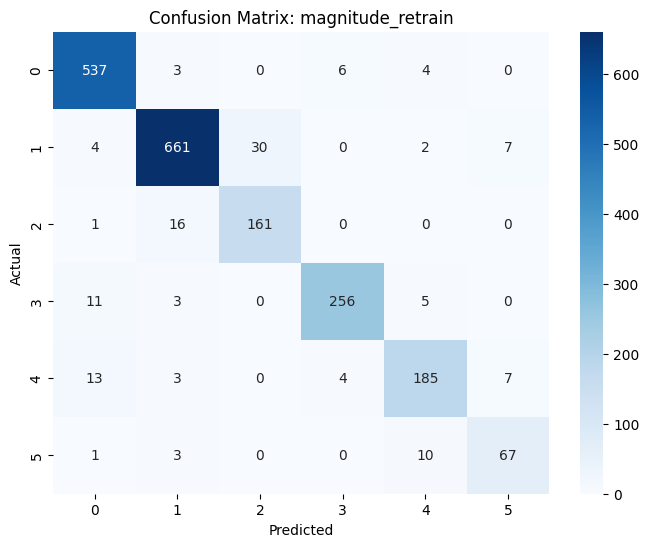


Processing: ./Twitter_RoBERTa_Head_Pruned


/tmp/ipython-input-2726444504.py:37: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Starting 2 Epochs of Fine-tuning...


Step,Training Loss
500,0.126600
1000,0.086900


Generating Predictions...



>>> Final Macro F1 Score: 0.9047

>>> Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.97      0.96       550
           1       0.96      0.94      0.95       704
           2       0.85      0.90      0.87       178
           3       0.94      0.93      0.93       275
           4       0.89      0.87      0.88       212
           5       0.85      0.81      0.83        81

    accuracy                           0.93      2000
   macro avg       0.91      0.90      0.90      2000
weighted avg       0.93      0.93      0.93      2000



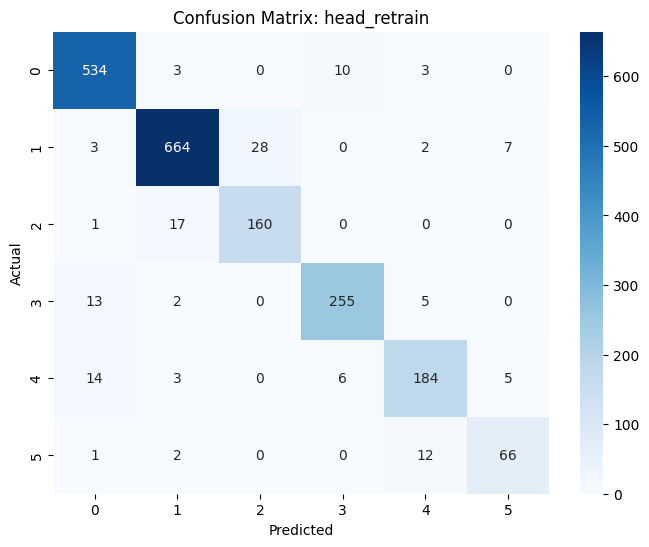

In [ ]:
# 1. Define a Reusable Function for Retraining & Evaluating
def retrain_and_evaluate(model_path, output_dir_name, train_data, val_data):
    print(f"\n{'='*20}\nProcessing: {model_path}\n{'='*20}")

    # Load Pruned Model & Tokenizer
    model = AutoModelForSequenceClassification.from_pretrained(model_path)
    tokenizer = AutoTokenizer.from_pretrained(model_path)

    # For the Magnitude pruning - this freezes the weights which are pruned to stay pruned
    if "Magnitude" in model_path:
        print("Re-applying masks to freeze zeroed weights...")
        for name, module in model.named_modules():
            if isinstance(module, torch.nn.Linear):
                # Identify which weights are currently zero
                mask = (module.weight != 0).float()

                # Check if this layer was actually pruned (if it has zeros)
                if torch.sum(mask) < module.weight.numel():
                    # Apply the Pytorch Pruning Hook
                    # This locks the zeros in place during training
                    prune.custom_from_mask(module, 'weight', mask)

    # Training Arguments
    retrain_args = TrainingArguments(
        learning_rate=2e-5,
        per_device_train_batch_size=32,
        per_device_eval_batch_size=32,
        num_train_epochs=1,
        weight_decay=0.01,
        save_strategy="no",
        report_to="none"
    )

    # Initialize Trainer
    trainer = Trainer(
        model=model,
        args=retrain_args,
        train_dataset=train_data,
        eval_dataset=val_data,
        tokenizer=tokenizer
    )

    # Train (Fine-tune)
    print("Starting 1 Epoch of Fine-tuning...")
    trainer.train()

    # Evaluation
    print("Generating Predictions...")
    predictions_output = trainer.predict(val_data)
    y_pred = np.argmax(predictions_output.predictions, axis=-1)
    y_true = predictions_output.label_ids

    # Metrics
    # 1. Macro F1
    macro_f1 = f1_score(y_true, y_pred, average='macro')
    print(f"\n>>> Final Macro F1 Score: {macro_f1:.4f}")

    # 2. Classification Report
    print("\n>>> Classification Report:")

    print(classification_report(y_true, y_pred))

    # 3. Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels="auto",
                yticklabels="auto")
    plt.title(f'Confusion Matrix: {output_dir_name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()


# Execute for Both Pruned Models

# A. Retrain Magnitude Pruned Model
retrain_and_evaluate(
    model_path="./Twitter_RoBERTa_Magnitude_Pruned",
    output_dir_name="magnitude_retrain",
    train_data=tokenized_train,
    val_data=tokenized_val
)

# B. Retrain Head Pruned Model
retrain_and_evaluate(
    model_path="./Twitter_RoBERTa_Head_Pruned",
    output_dir_name="head_retrain",
    train_data=tokenized_train,
    val_data=tokenized_val
)

# Compression - Distillation

For this method we use the DeBERTa V3 model as the teacher and the DeBERTa V3 Xsmall model (from https://huggingface.co/microsoft/deberta-v3-xsmall) as the student.<br>
We use the similar method as DistillBERT that we learned in Lecture on Compression (slide 27).
Temperature=4
We compare between the hard and soft results of the teacher and the student with alpha=0.5 weight given to each - the hard and soft. The difference in the softmax is measured by Kullback-Leibler Divergence measure. We train the student this way for 5 epochs

The tokenizer you are loading from './DeBERTa_V3_model' with an incorrect regex pattern: https://huggingface.co/mistralai/Mistral-Small-3.1-24B-Instruct-2503/discussions/84#69121093e8b480e709447d5e. This will lead to incorrect tokenization. You should set the `fix_mistral_regex=True` flag when loading this tokenizer to fix this issue.


Tokenizing datasets


Map:   0%|          | 0/16000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]


Initializing Student Model: microsoft/deberta-v3-xsmall...


Some weights of DebertaV2ForSequenceClassification were not initialized from the model checkpoint at microsoft/deberta-v3-xsmall and are newly initialized: ['classifier.bias', 'classifier.weight', 'pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipython-input-2285738638.py:40: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `DistillationTrainer.__init__`. Use `processing_class` instead.
  super().__init__(*args, **kwargs)
The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 2, 'bos_token_id': 1}.


Starting Distillation Training


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,1.906400,0.658995,0.863000,0.698808
2,0.398600,0.241981,0.928000,0.901091
3,0.174200,0.200855,0.935500,0.908143
4,0.127300,0.161831,0.932000,0.906799
5,0.108100,0.144916,0.936000,0.912461



Generating final evaluation on Validation Set



Final Macro F1 Score: 0.9125

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.95      0.96       550
           1       0.95      0.97      0.96       704
           2       0.95      0.83      0.88       178
           3       0.93      0.93      0.93       275
           4       0.87      0.90      0.88       212
           5       0.81      0.93      0.86        81

    accuracy                           0.94      2000
   macro avg       0.91      0.92      0.91      2000
weighted avg       0.94      0.94      0.94      2000


Confusion Matrix:


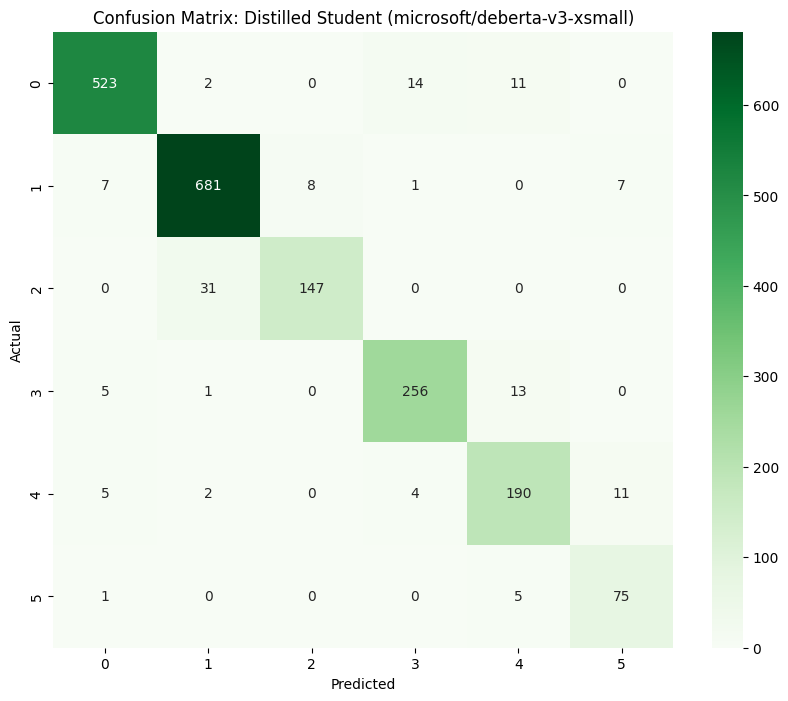

In [ ]:
import torch.nn.functional as F


# Convert Pandas to Hugging Face Dataset
train_dataset = Dataset.from_pandas(train_df[['text', 'label']])
val_dataset = Dataset.from_pandas(val_df[['text', 'label']])

save_directory = "./DeBERTa_V3_model"
tokenizer = AutoTokenizer.from_pretrained(save_directory)


# Tokenization Function
def tokenize_function(examples):
    return tokenizer(examples["text"], padding="max_length", truncation=True, max_length=128)

print("Tokenizing datasets")

tokenized_train = train_dataset.map(tokenize_function, batched=True)
tokenized_val = val_dataset.map(tokenize_function, batched=True)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)

    acc = accuracy_score(labels, predictions)
    f1 = f1_score(labels, predictions, average='macro')

    return {
        'accuracy': acc,
        'f1_macro': f1
    }


# Define the Distillation Trainer
# This implements the DistilBERT method: Loss = alpha * Hard_Loss + (1-alpha) * Soft_Loss

class DistillationTrainer(Trainer):
    def __init__(self, *args, teacher_model=None, temperature=4.0, alpha=0.5, **kwargs):
        super().__init__(*args, **kwargs)
        self.teacher = teacher_model
        self.temperature = temperature
        self.alpha = alpha
        self.loss_fct = nn.KLDivLoss(reduction="batchmean")

    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        # 1. Student Forward Pass
        outputs = model(**inputs)
        student_logits = outputs.logits

        # 2. Teacher Forward Pass - with no gradient only just compute output
        with torch.no_grad():
            teacher_outputs = self.teacher(**inputs)
            teacher_logits = teacher_outputs.logits

        # 3. Calculate Distillation Loss
        # Soft Loss (KL Divergence): Match the smoothed probability distributions
        loss_soft = self.loss_fct(
            F.log_softmax(student_logits / self.temperature, dim=-1),
            F.softmax(teacher_logits / self.temperature, dim=-1)
        ) * (self.temperature ** 2)

        # Hard Loss (Cross Entropy): Standard training on true labels
        loss_hard = outputs.loss

        # Combined Loss
        loss = self.alpha * loss_hard + (1 - self.alpha) * loss_soft

        return (loss, outputs) if return_outputs else loss


# 3. Initialize Teacher and Student

# Load Teacher (DeBERTa V3 Base)
teacher_model = AutoModelForSequenceClassification.from_pretrained(save_directory)
teacher_model.eval()
teacher_model.to("cuda" if torch.cuda.is_available() else "cpu")

# Initialize Student
# We use 'deberta-v3-xsmall'
student_model_name = "microsoft/deberta-v3-xsmall"
print(f"\nInitializing Student Model: {student_model_name}...")

student_model = AutoModelForSequenceClassification.from_pretrained(
    student_model_name,
    num_labels=6,
    ignore_mismatched_sizes=True
)


# Train Student (Knowledge Distillation)
distill_args = TrainingArguments(
    learning_rate=5e-5,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,
    num_train_epochs=5,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    report_to="none"
)

distill_trainer = DistillationTrainer(
    model=student_model,
    teacher_model=teacher_model,
    args=distill_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_val,
    compute_metrics=compute_metrics,
    tokenizer=tokenizer,
    temperature=4.0,
    alpha=0.5
)

print("Starting Distillation Training")
distill_trainer.train()


# Final Evaluation & Reports

print("\nGenerating final evaluation on Validation Set")
predictions_output = distill_trainer.predict(tokenized_val)
y_pred = np.argmax(predictions_output.predictions, axis=-1)
y_true = predictions_output.label_ids

# 1. Macro F1
macro_f1 = f1_score(y_true, y_pred, average='macro')
print(f"\nFinal Macro F1 Score: {macro_f1:.4f}")

# 2. Classification Report
print("\nClassification Report:")

print(classification_report(y_true, y_pred))

# 3. Confusion Matrix
print("\nConfusion Matrix:")
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels="auto",
            yticklabels="auto")
plt.title(f'Confusion Matrix: Distilled Student ({student_model_name})')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Running on Test dataset

In [ ]:
def run_inference(model_directory, csv_path):

    print(f"--- Loading model from {model_directory} ---")
    
    # 1. Load Model & Tokenizer
    # We load the tokenizer specifically from the saved directory
    tokenizer = AutoTokenizer.from_pretrained(model_directory)
    model = AutoModelForSequenceClassification.from_pretrained(model_directory)
    
    # Check for GPU
    device = "cuda" if torch.cuda.is_available() else "cpu"
    model.to(device)
    print(f"Model loaded on {device.upper()}")

    # 2. Load and Prepare Data
    print(f"Reading data from {csv_path}...")
    df = pd.read_csv(csv_path)
        
    # Convert to Hugging Face Dataset
    hf_dataset = Dataset.from_pandas(df)

    # Define Tokenization Logic
    def tokenize_function(examples):
        return tokenizer(examples["text"], padding="max_length", truncation=True, max_length=128)

    print("Tokenizing data...")
    tokenized_dataset = hf_dataset.map(tokenize_function, batched=True)

    # 3. Setup Inference Trainer
    trainer = Trainer(
        model=model,
        args=TrainingArguments(
            per_device_eval_batch_size=32,
            report_to="none"
        ),
        tokenizer=tokenizer
    )

    # 4. Run Prediction
    print("Running inference...")
    predictions_output = trainer.predict(tokenized_dataset)
    
    # Convert raw logits to class indices
    logits = predictions_output.predictions
    predicted_labels = np.argmax(logits, axis=-1)

    # 5. Attach results to DataFrame
    df['predicted_label'] = predicted_labels
    
    print("Done!")
    return df


# Example Usage
# Assuming 'test_data.csv'
# Assuming model is saved in './Twitter_RoBERTa_model' - please change the model folder

final_df = run_inference(
    # Please change these paths to the model and test file
    model_directory="./Twitter_RoBERTa_model",
    csv_path="test_data.csv"
)
